# Basic bioIB pipeline

This code exemplifies the basic implementation of the bioIB package for generating signal-specific metagenes from scRNA-seq data

In [1]:
import os
import numpy as np
from scipy.io import mmread
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import matplotlib
import seaborn as sns
import time
import kneed
import matplotlib
matplotlib.rcParams.update({'font.size': 20})
import scanpy as sc
import jax
import jax.numpy as jnp
from jax import jit


/cs/labs/mornitzan/sima_dubnov/venv_1103z/lib/python3.9/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.2' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/cs/labs/mornitzan/sima_dubnov/venv_1103z/lib/python3.9/site-packages/pandas/core/arrays/masked.py:59: UserWarning: Pandas requires version '1.3.2' or newer of 'bottleneck' (version '1.2.1' currently installed).
  from pandas.core import (


In [2]:
import bioIB_py as bioIB


In [11]:
importlib.reload(bioIB)

<module 'bioIB_py' from '/cs/labs/mornitzan/sima_dubnov/Benchmarking/Immune_atlas/bioIB_py/__init__.py'>

# Opening and preprocessing the scRNA-seq data

We start by opening the scRNA-seq data that is to be processed with bioIB. For that aim, we implement the scanpy package and read the file as an AnnData object. 
We further perform basic data preprocessing - normalzation by total counts and transformation to logspace. 

In [3]:
#Opening data
adata=sc.read_h5ad('filtered_processed_macrophage_adata.h5ad')
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 108197 × 27672
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation', 'Age_categorical', 'Development_stage'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var', 'n_cells'
    uns: 'Age_categorical_colors', 'Development_stage_colors', 'leiden', 'organ_colors', 'scvi', 'umap', 'log1p'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'scvi_connectivities', 'scvi_distances'

We further implement scanpy to reduce the original data to the selected number of highly variable genes, as shown below. 

In [4]:
#Highly variable genes
n_hv_genes=500
hv_1e4=sc.pp.highly_variable_genes(adata, n_top_genes=n_hv_genes, min_mean=0.0125, max_mean=3, min_disp=0.5)
data_1e4=adata[:, adata.var.highly_variable]
data_1e4

View of AnnData object with n_obs × n_vars = 108197 × 500
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation', 'Age_categorical', 'Development_stage'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var', 'n_cells'
    uns: 'Age_categorical_colors', 'Development_stage_colors', 'leiden', 'organ_colors', 'scvi', 'umap', 'log1p', 'hvg'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'scvi_connectivities', 'scvi_distances'

# Setting the parameters for bioIB analysis

After basic data preprocessing, we need to set the appropriate parameters for bioIB.

First, we select the signal of interest Y, with respect to which the bioIB metagenes will be generated. Here, we set Y to be the organ of origin. 

In [5]:
Y='organ'

Next, we can select specific groups out of all Y labels to focus the analysis on them. We will define those groups in the list Y_vals, as shown below:

In [6]:
Y_vals=['YS', 'SP', 'LI', 'SK', 'KI']

The function bioIB.pp.get_probability_matrices() utilizes the preprocessed AnnData object and the selected signal of interest to generate the probability matrices needed for bioIB initialization:

In [7]:
[p_x, p_y, p_y_x_state, p_xy, p_y_x]=bioIB.pp.get_probability_matrices(data_1e4, Y, Y_vals)

# Sorting by Information Gain 

Optionally, we can further sort and filter the highly variable genes, selected by scanpy, using the Information Gain values, representing the relative contribution of each gene to the mutual information between genes (x) and cell types of interest (y). 
The function bioIB.pp.sort_by_infogain() uses the probability matrices generated by bioIB.get_probability_matrices() to calculate the information gain value for every gene and returns the genes sorted by information gain in decreasing order, together with their corresponding values, as shown below.

In [8]:
all_genes=list(data_1e4.var_names)
[sorted_indeces, sorted_gene_names, sorted_infogain]=bioIB.pp.sort_by_infogain(p_y_x_state, p_y, p_x, all_genes)

We can visualize the calculated information gain (infogain) values of all the genes.

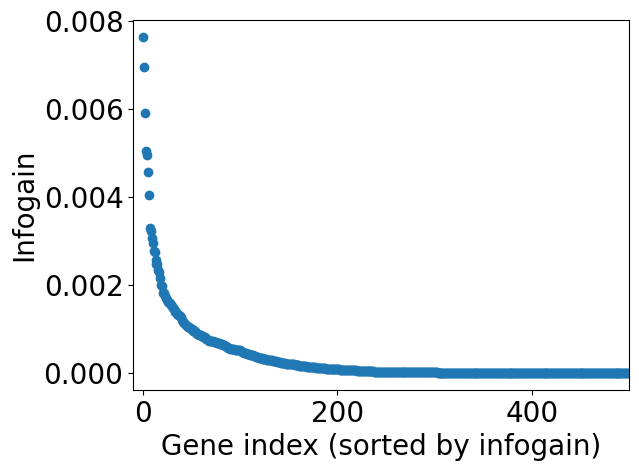

In [9]:
plt.scatter(range(len(sorted_infogain)), sorted_infogain)
plt.xlabel('Gene index (sorted by infogain)')
plt.ylabel('Infogain')
plt.xlim(-10,500)
plt.show()

We further sort the genes by their infogain values for the bioIB input. This step is optional and mainly useful if the user intends to filter the genes further using the infogain and apply bioIB to N genes with the highest infogain values. 

p_x_sorted is the gene probability vector p_x, sorted by the decreasing infogain value


In [10]:
p_x_sorted=p_x[sorted_indeces]

y_given_x is the conditional probability matrix of cell labels (y) given the genes (x), in which genes are sorted by the decreasing infogain values

In [11]:
y_given_x=p_y_x_state[:,sorted_indeces]

data_filt is the original AnnData object in which enes are sorted by the decreasing infogain values.

In [12]:
data_filt=data_1e4[:, sorted_gene_names]
data_filt

View of AnnData object with n_obs × n_vars = 108197 × 500
    obs: 'n_counts', 'n_genes', 'file', 'mito', 'doublet_scores', 'predicted_doublets', 'old_annotation_uniform', 'organ', 'Sort_id', 'age', 'method', 'donor', 'sex', 'Sample', 'scvi_clusters', 'is_maternal_contaminant', 'anno_lvl_2_final_clean', 'celltype_annotation', 'Age_categorical', 'Development_stage'
    var: 'GeneID', 'GeneName', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'scvi_model_var', 'n_cells'
    uns: 'Age_categorical_colors', 'Development_stage_colors', 'leiden', 'organ_colors', 'scvi', 'umap', 'log1p', 'hvg'
    obsm: 'X_scvi', 'X_umap'
    obsp: 'scvi_connectivities', 'scvi_distances'

# Running hierarchical bioIB (reverse annealing)

The function bioIB.reverse_annealing() uses the generated probability matrices (either sorted by information gain or not) to produce a series of optimal gene clustering solutions {y_given_xHat; x_given_xHat} for each value of beta from the predefined initial beta to 1. This step might take some significant running time. The user can track the progression by the printed beta values. The function stops running at beta=1.

In [13]:
beta=20
[I_x_xhat, I_xhat_y, xHat_given_x_list, y_given_xHat_list, x_given_xHat_list, p_xHat_list, iters]=bioIB.reverse_annealing(beta, p_x_sorted, p_y, y_given_x)


beta=20.000000000000004
beta=17.211370738255045
beta=14.811564134483097
beta=12.746366076601513
beta=10.969121605495301
beta=9.439680931259147
beta=8.12349240793689
beta=6.9908219761201
beta=6.01608143980719
beta=5.177250402602835
beta=4.455378804198879
beta=3.8341588189215168
beta=3.2995564450904147
beta=2.8394944624124996
beta=2.4435795950901866
beta=2.1028677169766166
beta=1.8096617945196265
beta=1.5573380028166606
beta=1.3401960865625606
beta=1.153330585389339


# Downstream analysis

First, we reconstruct the beta values implemented in reverse annealing

In [14]:
#Reconstructing betas
num_betas=400
logbeta=np.log2(beta)
betas = 2**np.linspace(logbeta, 0, num_betas)

Next, we convert the lists from the reverse annealing output to numpy arrays

In [15]:

res=[I_x_xhat, I_xhat_y, xHat_given_x_list, y_given_xHat_list, x_given_xHat_list, p_xHat_list, betas, iters]
    
[I_x_xhat_arr, I_xhat_y_arr, xHat_x_arr, y_xHat_arr, x_xHat_arr, p_xHat_arr, betas, iters]=[np.asarray(l) for l in res]


During the run of reverse annealing, some metagenes might collapse (their probability might go down to zero). We filter such metagenes out and do not refer to them in the downstream analysis. The function bioIB.al.filter_collapsed_genes() redefines the reverse annealing output, filtering out all the collapsed metagenes.

In [16]:
[y_xHat_arr, xHat_x_arr, x_xHat_arr, p_xHat_arr]=bioIB.al.filter_collapsed_genes(y_xHat_arr, xHat_x_arr, x_xHat_arr, p_xHat_arr)

The function bioIB.al.get_compressed_matrices() compresses the reverse annealing output matrices to unique metagenes based on one of the conditional probability matrices (p(y|xHat) or p(x|xHat)). 

In [17]:
[n_metagenes_y, compressed_matrices_y, unique_indeces_list_y]=bioIB.al.get_compressed_matrices(betas, y_xHat_arr)
[n_metagenes_x, compressed_matrices_x, unique_indeces_list_x]=bioIB.al.get_compressed_matrices(betas, x_xHat_arr)

After running bioIB.al.get_compressed_matrices() on both y_xHat_arr and x_xHat_arr, we implement the function bioIB.al.get_selected_indeces() to compare the unique metagenes and select only the solutions that yielded the same clustering results both based on y_xHat_arr and x_xHat_arr.

In [18]:
[selected_indeces, n_clus]=bioIB.al.get_selected_indeces(n_metagenes_x, unique_indeces_list_x, unique_indeces_list_y)

The function bioIB.al.get_representative_genes() can be used to save the csv table with the conditional probability values of all genes given all the metagenes, for each of the generated metagene numbers. It also returns a dictionary mapping every metagene to the index of its most representative gene.

In [19]:
representative_genes=bioIB.al.get_representative_genes(compressed_matrices_x, selected_indeces, n_clus)

# Plotting the output

The function bioIB.pl.plot_bifurcations() plots the bioIB hierarchy for each cell type Y at the selected depth. 
Setting depth=1 will plot the initial single metagene, to which all the metagenes eventually collapse, depth 2 will plot the metagenes associated with the first bifurcation, etc.

9 metagenes


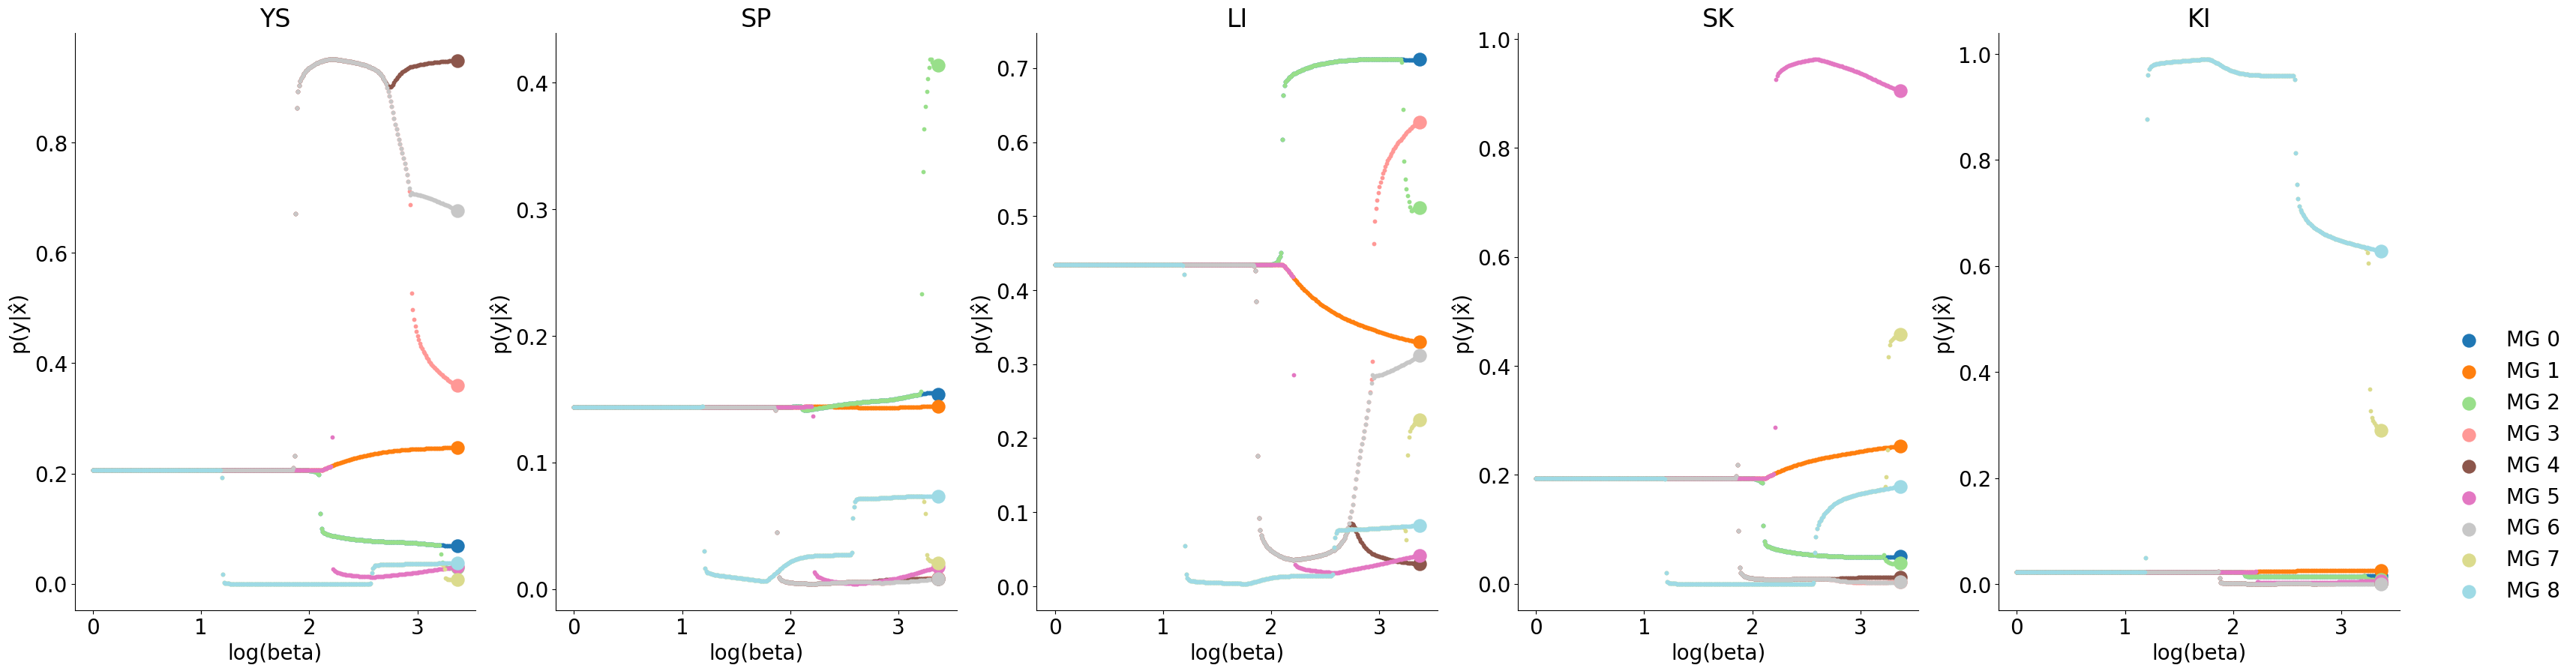

In [21]:

depth=8
n_metagenes=n_clus[depth-1]
bioIB.pl.plot_bifurcations(depth, selected_indeces, betas, compressed_matrices_y, 
                  unique_indeces_list_y, y_xHat_arr, Y_vals, 1,5,(40,10))
plt.show()

It is possible to reorder the metagenes and the cell types using the y_order and metagene_order parameters, as shown below. 

9 metagenes


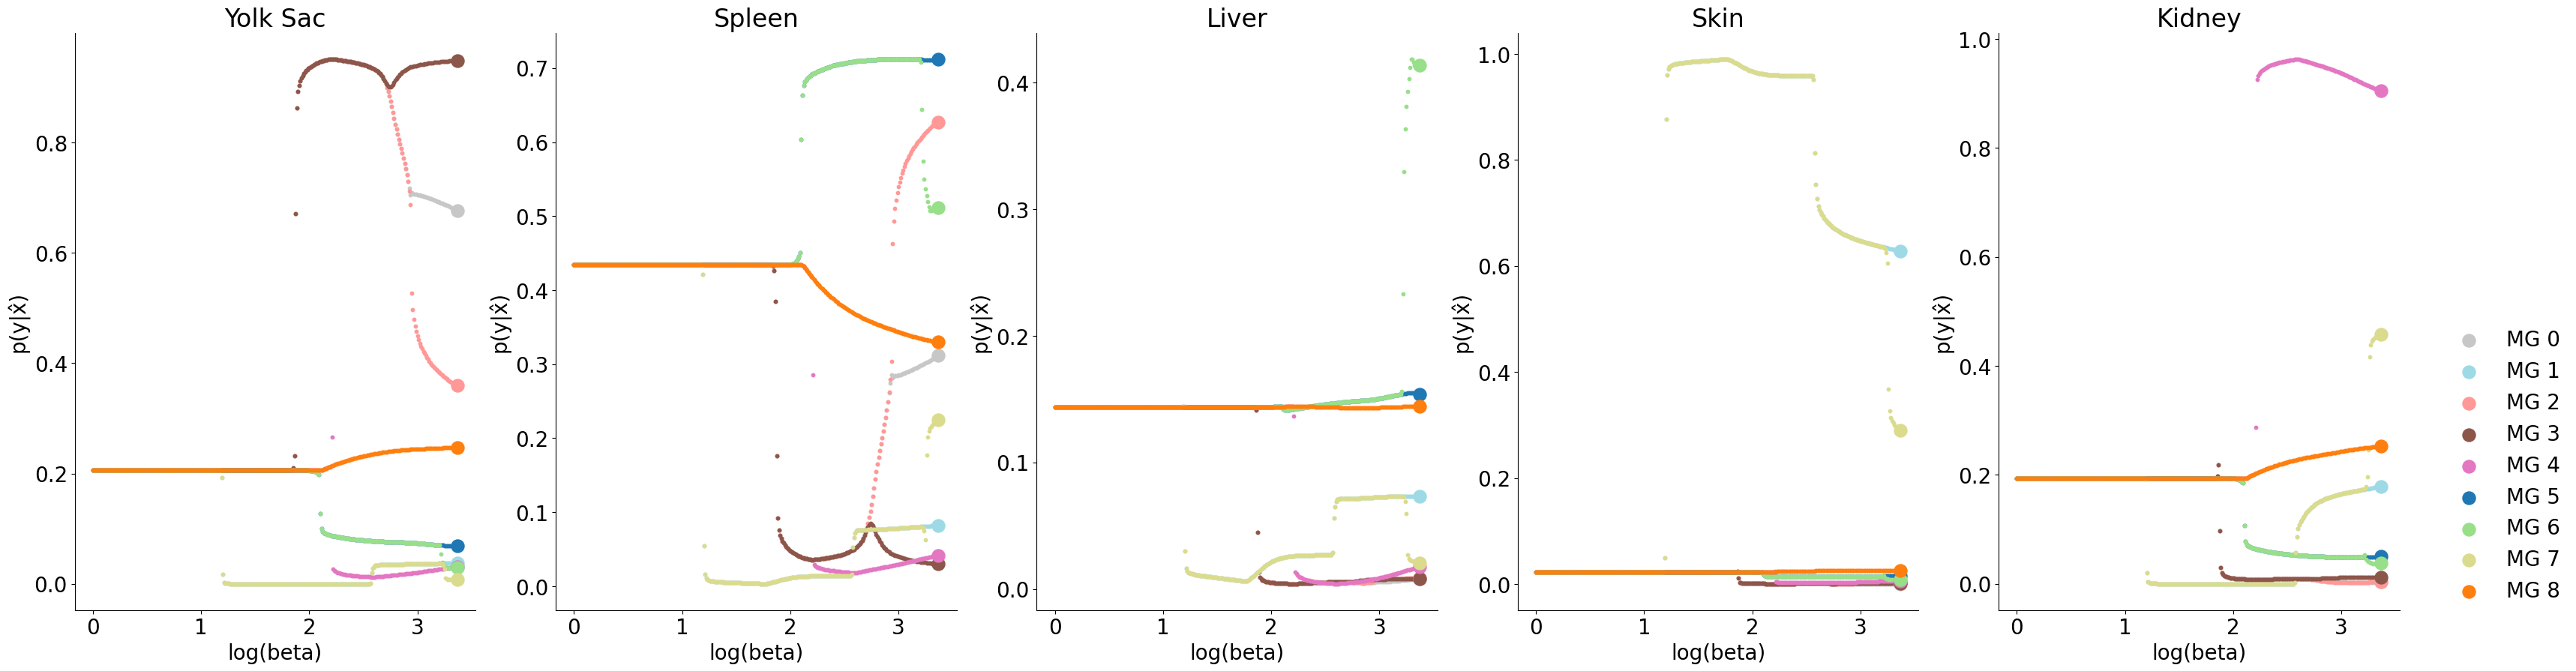

In [22]:

wanted_order=['YS','LI','SP','KI','SK']
full_titles=['Yolk Sac','Liver','Spleen','Kidney','Skin']
y_order=[]
for ct in wanted_order:
    y_order.append(list(Y_vals).index(ct))
    

metagene_order=[6,8,3,4,5,0,2,7,1]


bioIB.pl.plot_bifurcations(depth, selected_indeces, betas, 
                  compressed_matrices_y, unique_indeces_list_y,
                  y_xHat_arr, full_titles, 1,5,(40,10),
                  y_order=y_order, metagene_order=metagene_order)
plt.show()

The function bioIB.pl.plot_representative_genes() generates a heatmap of conditional probabilioty values (p(x|xHat)) for a selected number of most representative genes for each of the selected metagenes. 

[7, 37, 22, 100, 151, 191, 0, 1, 5, 65]


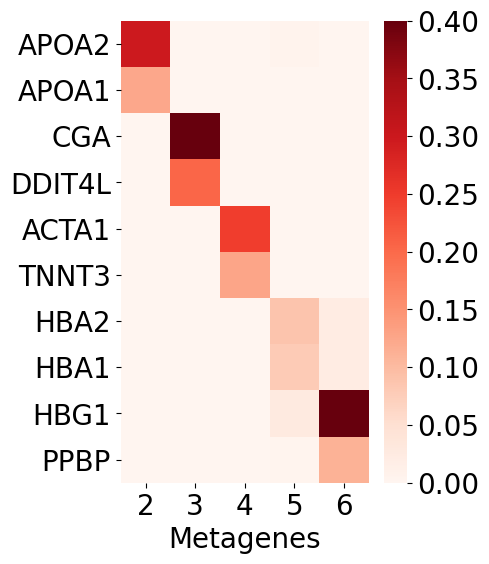

In [23]:
#%% Plotting representative genes

metagenes_to_show=[2,3,4, 5,6]
bioIB.pl.plot_representative_genes(depth, selected_indeces,
                          compressed_matrices_x, sorted_gene_names, 
                          metagenes_to_show, (4,6), 0.4, 2,
                          metagene_order=metagene_order)
plt.show()

We can annotate the original AnnData object with the single-cell expression values of the produced metagenes, using the function bioIB.al.annotate_bioIB_metagenes()

In [24]:
bioIB.al.annotate_bioIB_metagenes(data_filt, depth, selected_indeces, compressed_matrices_x)

/cs/labs/mornitzan/sima_dubnov/Benchmarking/Immune_atlas/bioIB_py/analysis.py:224: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  def get_bioIB_compressed_adata(adata, depth, selected_indeces, compressed_matrices_x, metagene_order=None):


Now we can visualize the expression of the bioIB metagenes at the single-cell level in the original data

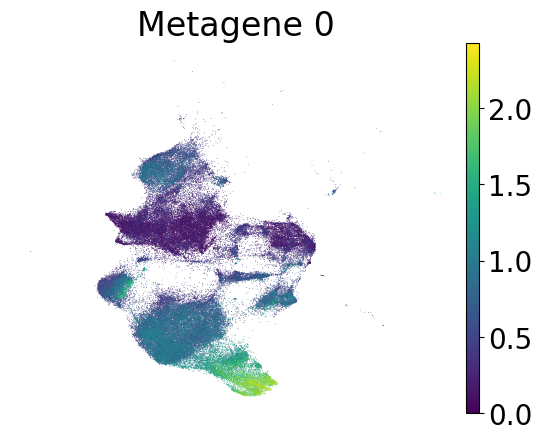

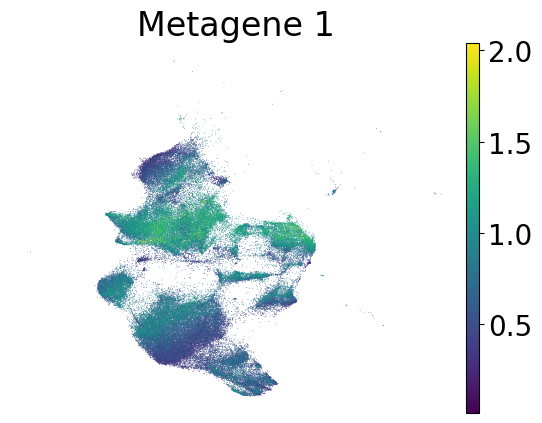

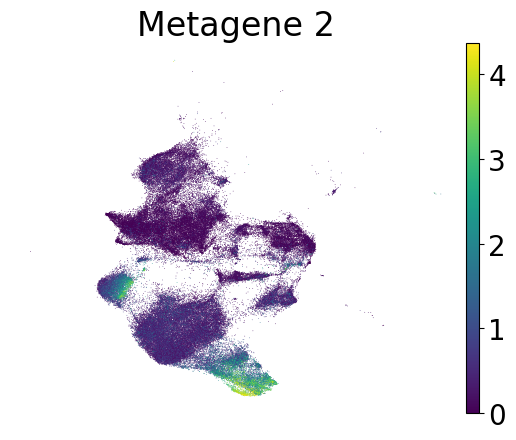

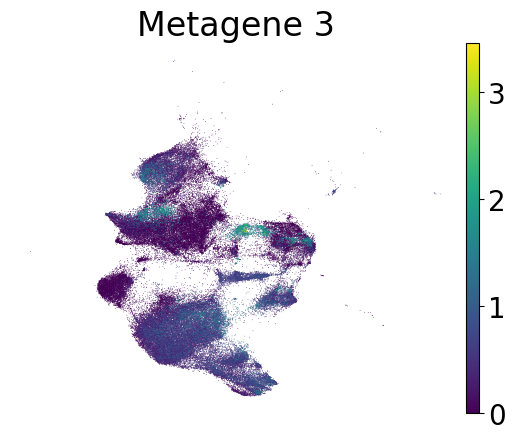

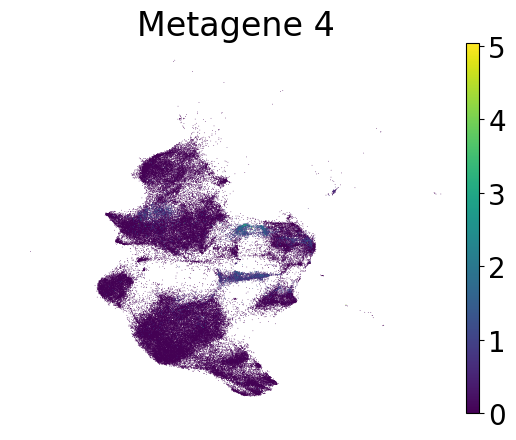

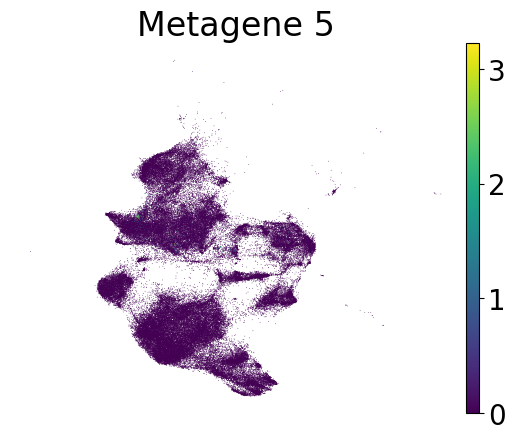

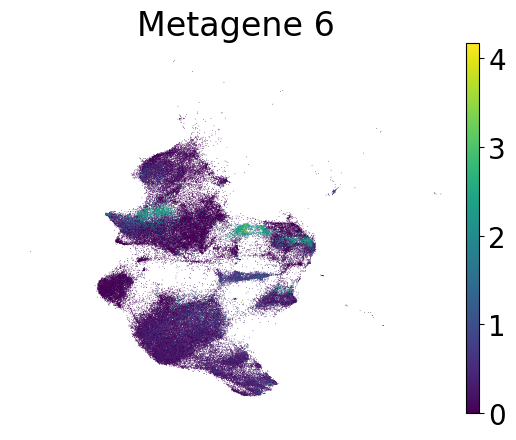

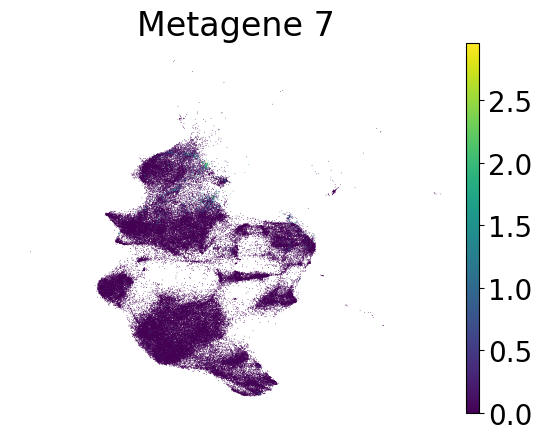

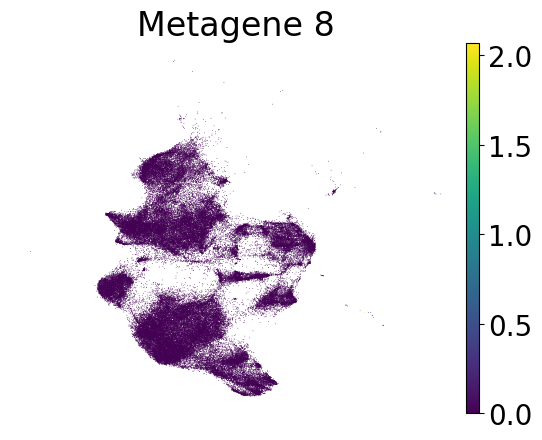

In [25]:
for n in range(n_metagenes):
    sc.pl.umap(data_filt, color=['Metagene %s' % n], frameon=False)

The function bioIB.al.get_bioIB_compressed_adata() generates a new AnnData object representing the compressed data of cells by metagenes. Implementing scanpy, we calculate a UMAP representation of the compressed data to visualize the separation between the labels.

In [26]:
#%% Compressed adata UMAPs
compressed_adata=bioIB.al.get_bioIB_compressed_adata(data_filt, depth, selected_indeces, compressed_matrices_x)
sc.pp.neighbors(compressed_adata)
sc.tl.umap(compressed_adata)

/cs/labs/mornitzan/sima_dubnov/Benchmarking/Immune_atlas/bioIB_py/analysis.py:253: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.


/cs/labs/mornitzan/sima_dubnov/venv_1103z/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


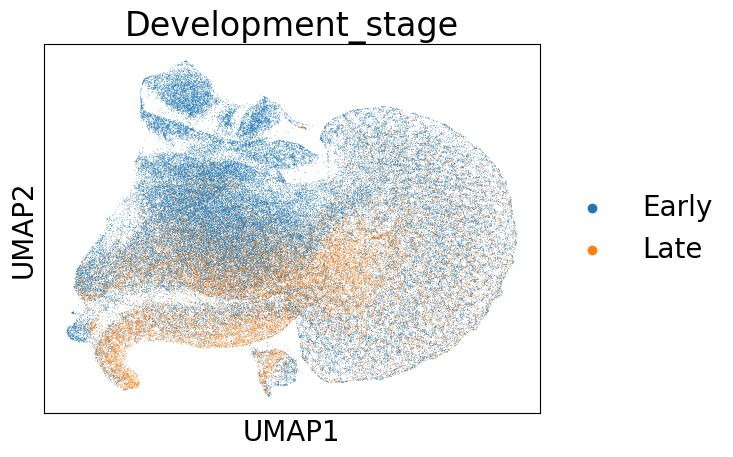

/cs/labs/mornitzan/sima_dubnov/venv_1103z/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


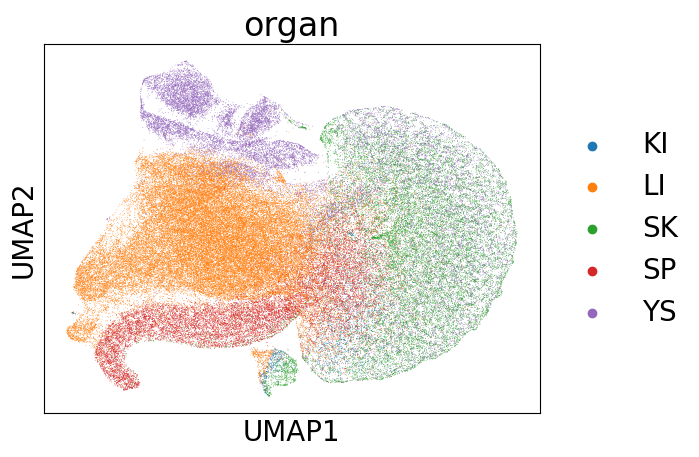

In [27]:
sc.pl.umap(compressed_adata, color='Development_stage')
sc.pl.umap(compressed_adata, color='organ')